# DSAC Coursework 1

**BSc Cyber Security - Artificial Intelligence Module**

--- 

### **Objective**
In this notebook, we will build, train, and evaluate 2 different supervised learning models to classify network traffic as either `normal` or `malicious`.
Using the CIC-IDS2017 dataset from [UNB](https://www.unb.ca/cic/datasets/ids-2017.html).

## 1. Exploratory data analysis (EDA)
### 1.1 Imports

Special imports required if running notebook:

- lightgbm   - command to install: "pip install lightgbm"   (Required for LightGBM model)

- joblib - command to install if not instead "pip install joblib"   (Required for opening saved models)

In [ ]:
# Importing libraries
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier  # https://lightgbm.readthedocs.io/en/latest/Python-Intro.html
from pathlib import Path
import joblib  # https://joblib.readthedocs.io/en/latest/
import os


### 1.2 Creating DataFrame

In [20]:
# Folder containing Tuesday–Friday CSV files (excluding Monday)
DATA_DIR = Path("./CSVs")


# Collect CSV file paths
csv_files = list(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV files found.")


df_list = []

for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Merge into one DataFrame
df = pd.concat(df_list, ignore_index=True)
for d in df_list: # Free memory
    del d  
df.columns = df.columns.str.strip() # Remove leading/trailing spaces from column names which causes parsing issues

### 1.3 Map attack label to binary values

In [21]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1) # Convert labels to binary (0 for Normal, 1 for Malicious)

### 1.4 Remove Missing/Infinity value rows

In [22]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Missing Values:\n", df.isna().sum().sort_values(ascending=False))
df = df.dropna() # Drop rows with missing values
print(f"Shape after removing missing values: {df.shape}")

Missing Values:
 Flow Bytes/s                   2059
Flow Packets/s                 2059
Flow Duration                     0
Total Backward Packets            0
Total Length of Fwd Packets       0
                               ... 
Idle Mean                         0
Idle Std                          0
Idle Max                          0
Idle Min                          0
Label                             0
Length: 79, dtype: int64
Shape after removing missing values: (2012299, 79)


### 1.5 Removing Duplicates

In [23]:
duplicates = df[df.duplicated()]
print(f'Number of duplicates: {len(duplicates)}')
df = df.drop_duplicates() # Remove duplicate rows
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicates: 198773
Shape after removing duplicates: (1813526, 79)


### 1.6 Label Distribution
To check the label distribution to identify any class imbalance between normal and malicious traffic.

0 - Normal

1 - Malicious

In [24]:
print("\nLabel counts:")
print(df['Label'].value_counts())


Label counts:
Label
0    1478479
1     335047
Name: count, dtype: int64


## 2. Data Preprocessing

### 2.1 Data Split
At this stage, training and test sets are split into features (X) and labels (y). This is done to ensure the model does not learn the attack_label, and follows supervised learning principles, where the model is trained on known examples (X_train), and tested on unseen data (y_test).

In [25]:
# Create new feature and label sets
features = df.drop("Label", axis=1)

# Split the data into features and labels
#features = df.drop("Label", axis=1)
labels = df["Label"]

# Split 60% train, 20% validation, 20% test

X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.4, stratify=labels, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(1088115, 78) (362705, 78) (362706, 78)


### 2.2 Correlation Analysis
Highly correlated features can introduce redundancy and multicollinearity. This is where two features are highly correlated, and the model is unable to tell how much each feature contributes to the outcome. To mitigate this, a correlation matrix is calculated, and features with a correlation greater than 0.95 are removed. 

By removing features with such high correlation, the model's complexity is reduced, which will help prevent overfitting and improve the model's generalisability. A visual heatmap is then plotted to allow for visual inspection of the correlation between features.

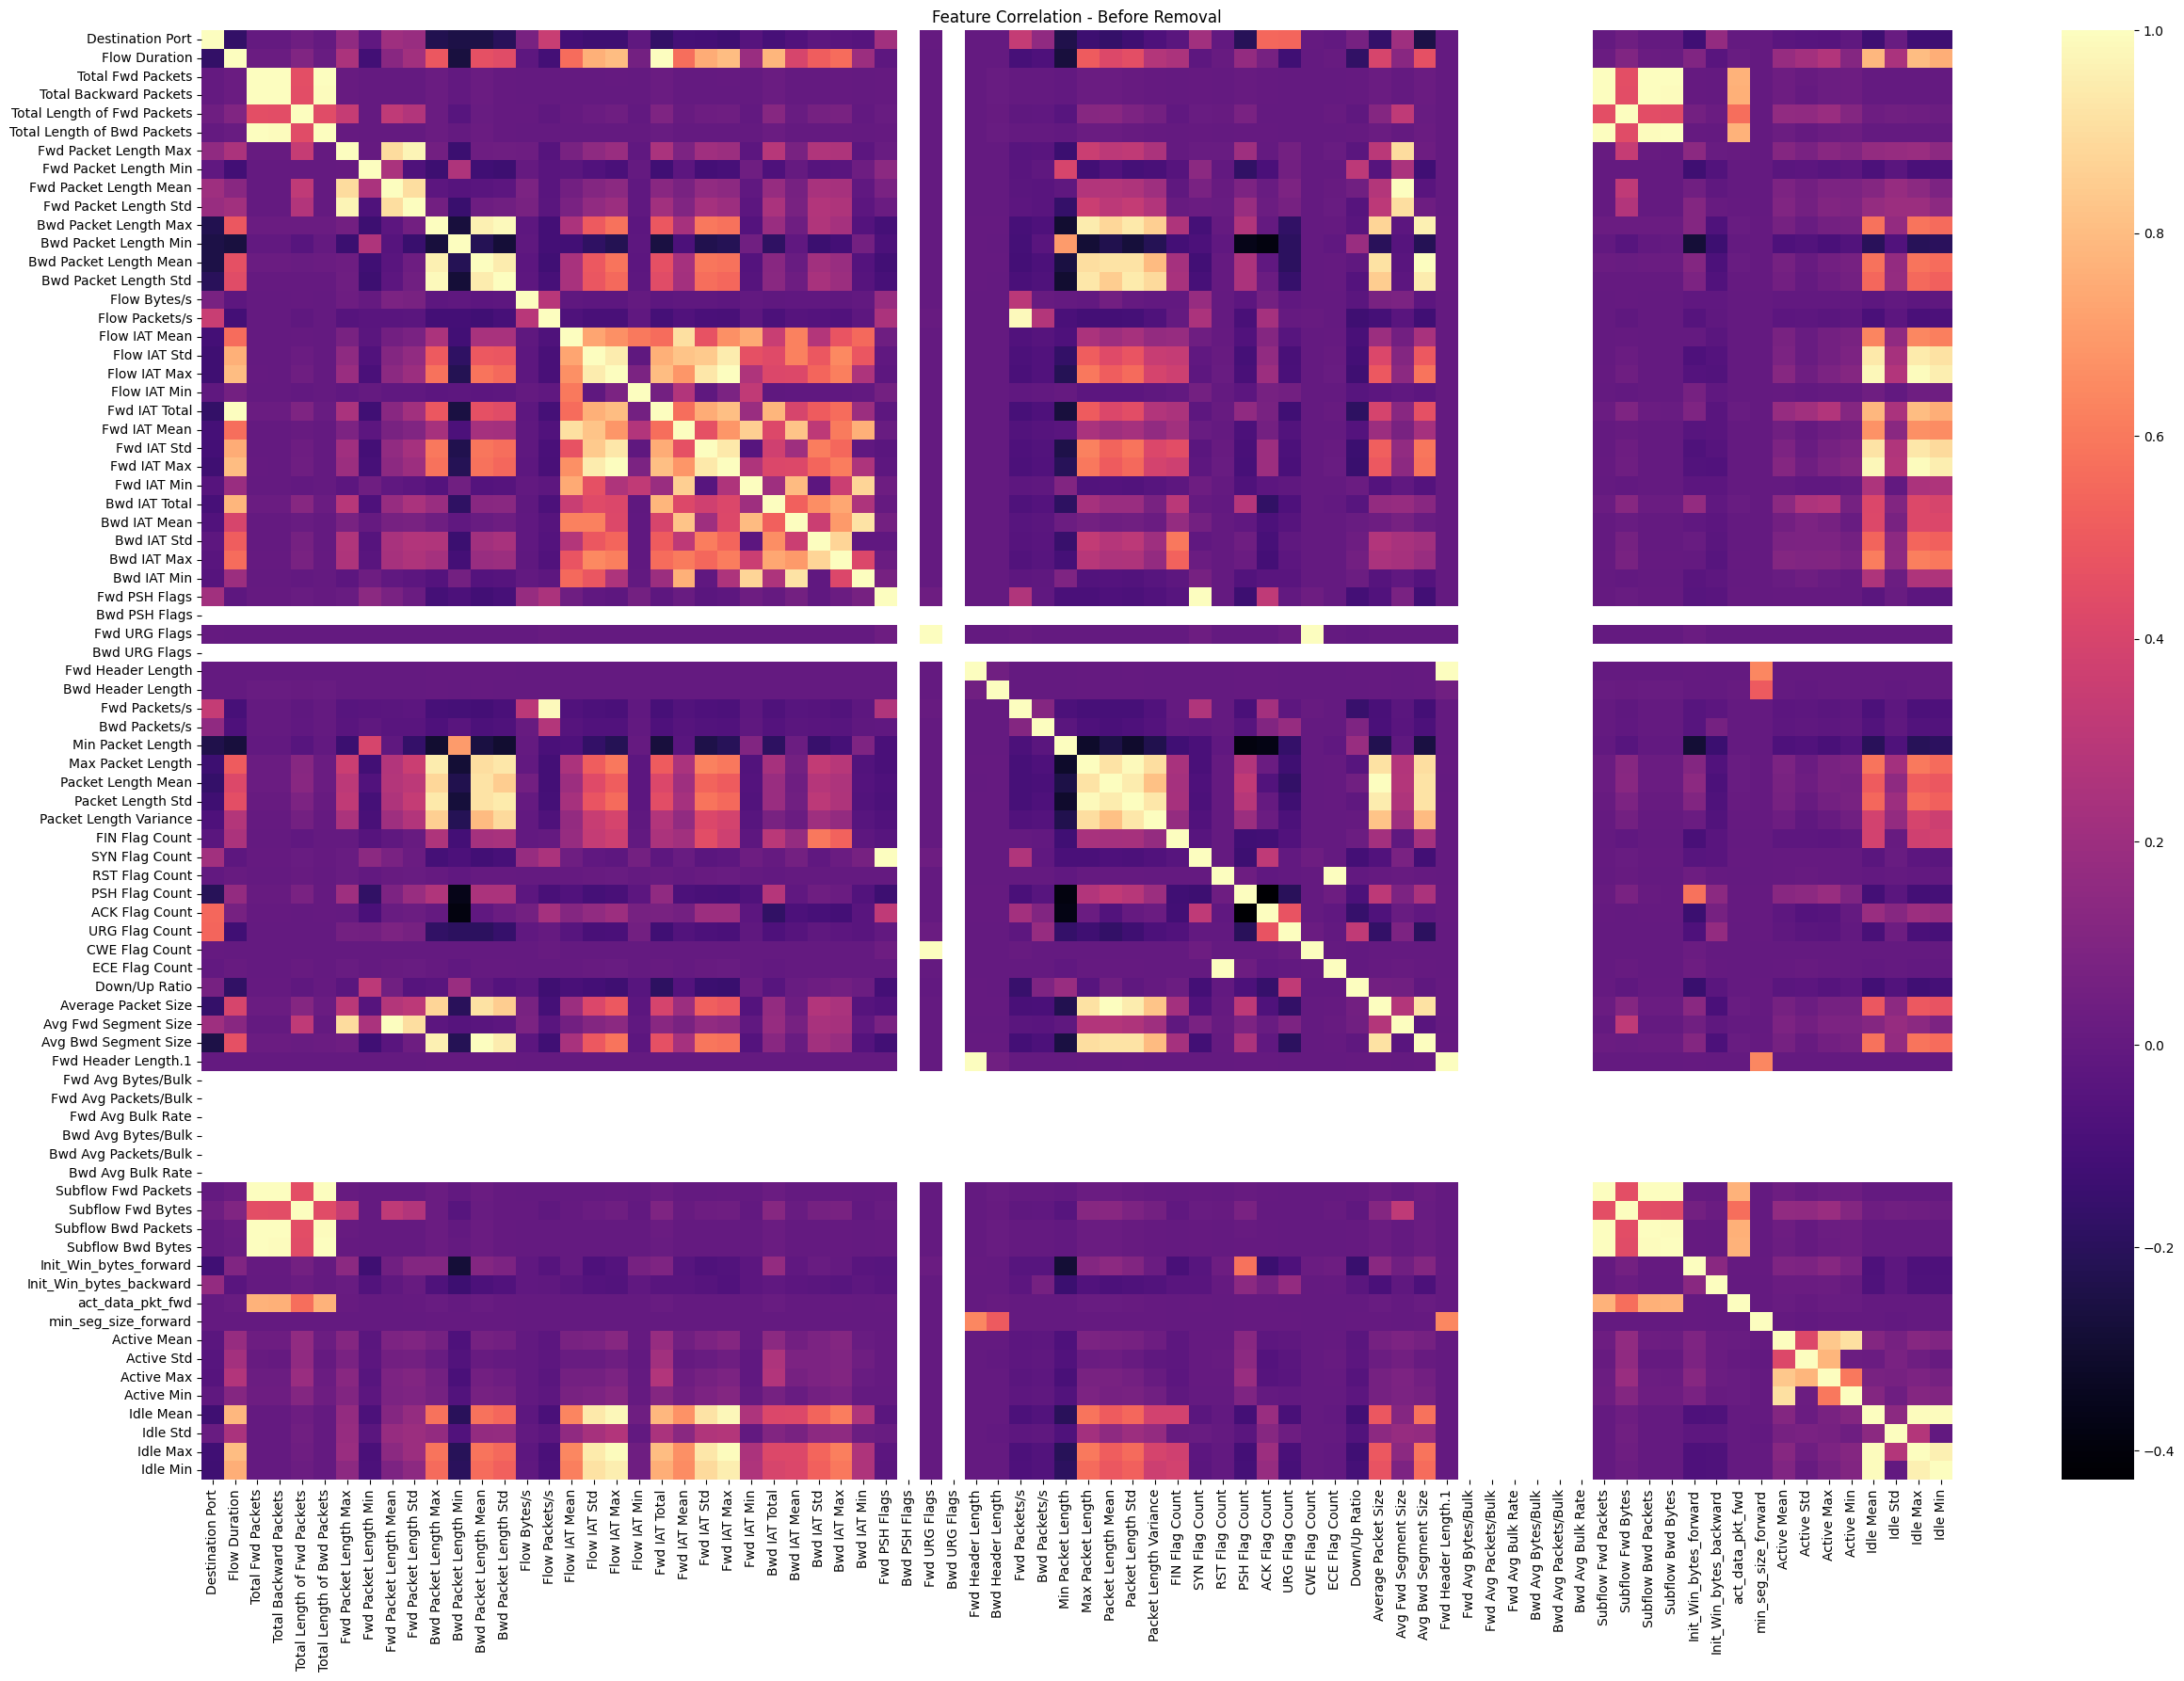

Dropping very highly correlated features: ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']
Number of features dropped: 23
(1088115, 78) (362705, 78) (362706, 78)


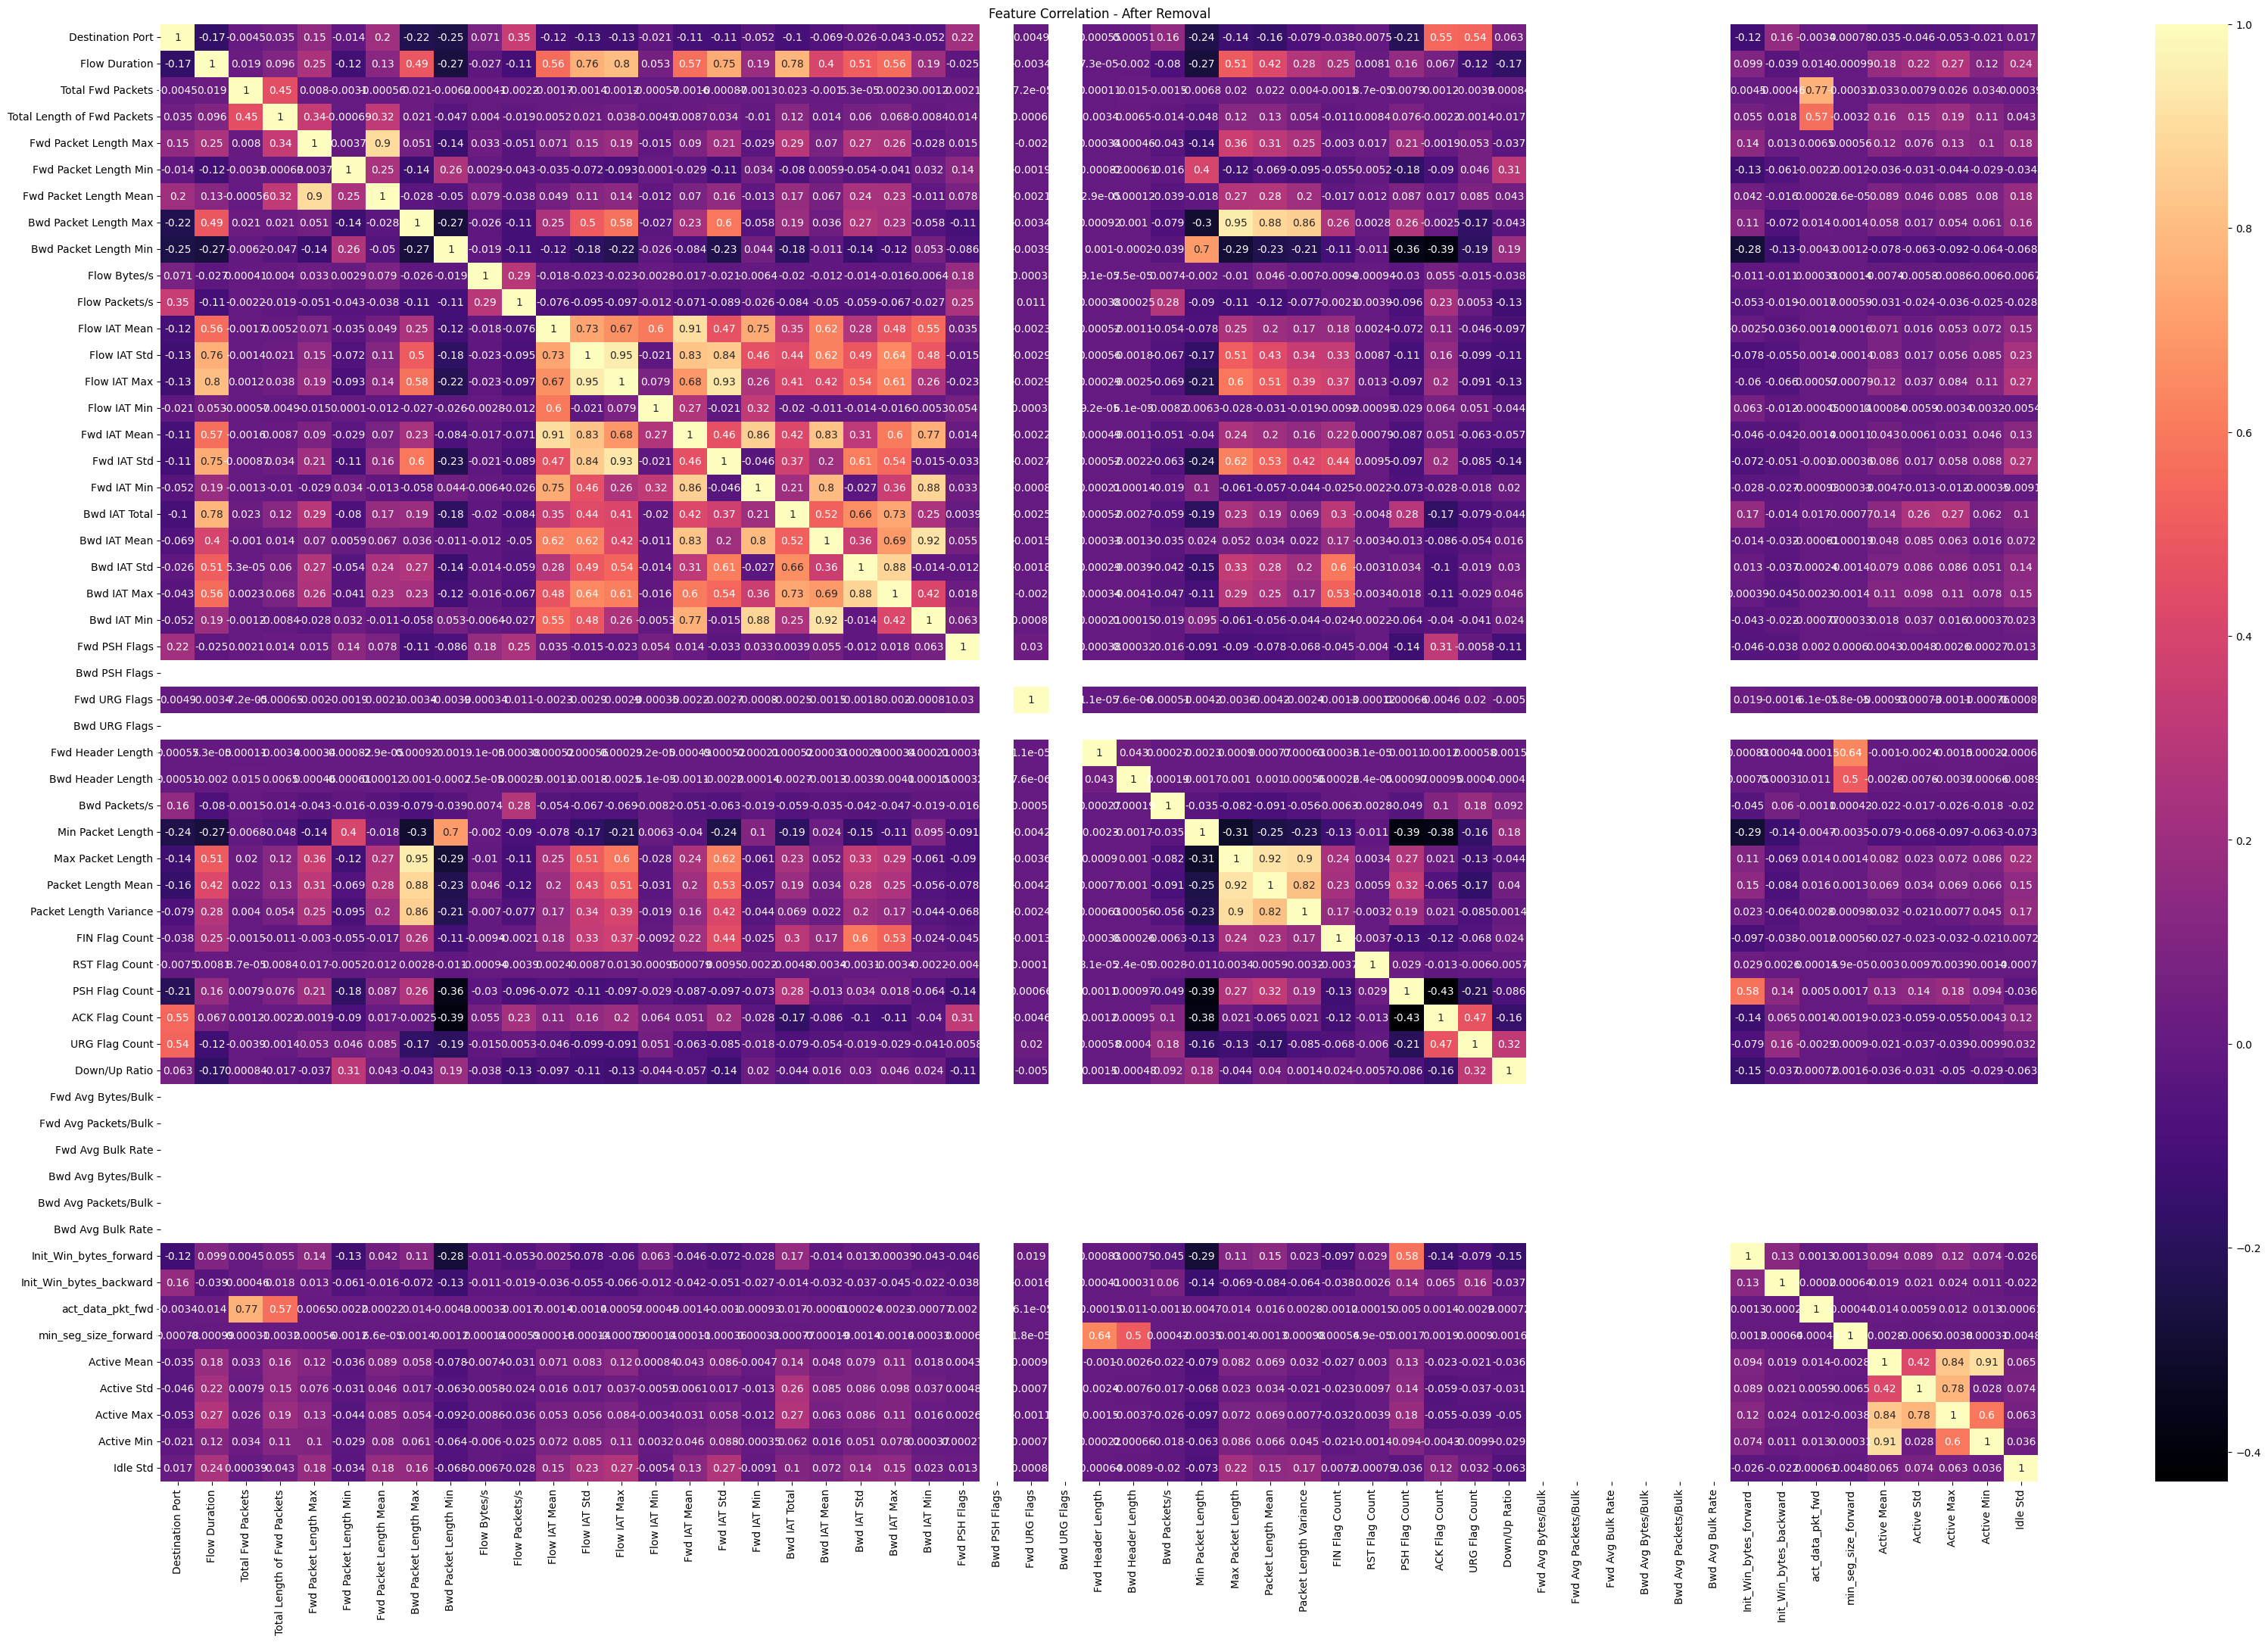

In [ ]:
plt.figure(figsize=(30, 20))
sns.heatmap(X_train.corr(), annot=False, cmap='magma') # Plot heatmap of feature correlations on training data
plt.title("Feature Correlation - Before Removal")
plt.show()

# Compute correlation matrix on training set
corr_matrix = X_train.corr()

# Select the upper triangle of the matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with a correlation greater than 0.95
correlated_features = [column for column in upper.columns if any(upper[column] > 0.95)]
print ("Dropping very highly correlated features: " + str(correlated_features))
print(f"Number of features dropped: {len(correlated_features)}")
# Drop the same features from ALL splits
X_train = X_train.drop(columns=correlated_features)
X_val   = X_val.drop(columns=correlated_features)
X_test  = X_test.drop(columns=correlated_features)
print(X_train.shape, X_val.shape, X_test.shape)

# Plot a heatmap for visual analysis
plt.figure(figsize=(40, 25))
sns.heatmap(X_train.corr(), annot=True, cmap='magma')
plt.title("Feature Correlation - After Removal")
plt.show()

### 2.3 Variance Selection
Features with very low variance don't contribute much to classification, and can be removed to reduce dimensionality and increase efficiency. A variance threshold of 0.01 is chosen to filter out features with variance below this threshold, while ensuring that any slightly meaningful features are retained for training. 

In [27]:
# Apply VarianceThreshold to remove features with very low variance
selector = VarianceThreshold(threshold=0.01)
X_train = selector.fit_transform(X_train)
X_val   = selector.transform(X_val)
X_test  = selector.transform(X_test)

selected_mask = selector.get_support()

print("Removed features (due to very low variance):")
print(X_train.shape, X_val.shape, X_test.shape)

Removed features (due to very low variance):
(1088115, 45) (362705, 45) (362706, 45)


### 2.4 Label Distribution

In [40]:
def label_distribution(y, name):
    counts = y.value_counts().sort_index()
    percentages = counts / counts.sum() * 100

    dist = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })

    print(f"\n{name} label distribution:")
    print(dist)
    return dist


dist_train = label_distribution(y_train, "Train")
dist_val   = label_distribution(y_val, "Validation")
dist_test  = label_distribution(y_test, "Test")

combined = pd.concat(
    {"Train": dist_train, "Validation": dist_val, "Test": dist_test},
    axis=1
)

combined


Train label distribution:
        Count  Percentage (%)
Label                        
0      887087           81.53
1      201028           18.47

Validation label distribution:
        Count  Percentage (%)
Label                        
0      295696           81.53
1       67009           18.47

Test label distribution:
        Count  Percentage (%)
Label                        
0      295696           81.52
1       67010           18.48


Train                Validation                   Test               
        Count Percentage (%)      Count Percentage (%)   Count Percentage (%)
Label                                                                        
0      887087          81.53     295696          81.53  295696          81.52
1      201028          18.47      67009          18.47   67010          18.48

### 2.5 PCA
Displays seperability of the data

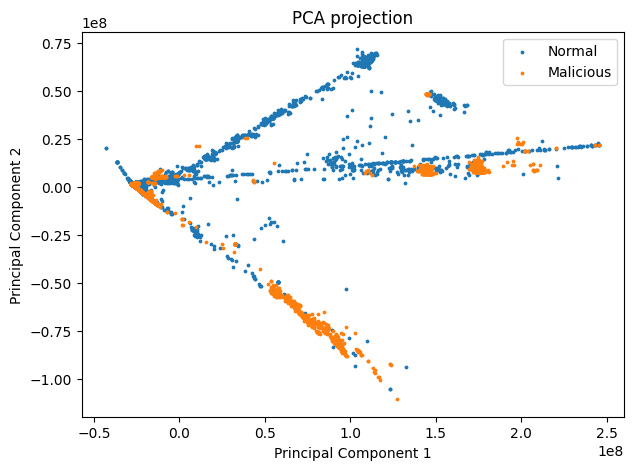

Variance explained by first two components: 76.39 %


In [43]:
# Use a subset so the plot is faster
sample_size = 15000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), size=sample_size, replace=False)

X_sample = X_train[idx]
y_sample = y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]

# Reduce features to 2 dimensions for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# Plot
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[y_sample == 0, 0],
    X_pca[y_sample == 0, 1],
    s=3,
    label="Normal"
)
plt.scatter(
    X_pca[y_sample == 1, 0],
    X_pca[y_sample == 1, 1],
    s=3,
    label="Malicious"
)

plt.title("PCA projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

print(
    "Variance explained by first two components:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)


## 3. Training Models


### 3.1 Training Random Forest Model
Class weighting applied due to imbalance.

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced", # Handle class imbalance
    n_jobs=-1 , # Use all available cores for parallel processing
    random_state=42
)

print("Training the Random Forest...")
rf_model.fit(X_train, y_train)
print("Training complete.")

Training the Random Forest...
Training complete.


### 3.2 Training LightGBM Model
Class weighting applied due to imbalance.

In [29]:
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    is_unbalance=True,  # optimising for imbalance
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM...")
lgbm_model.fit(X_train, y_train)
print("Training complete.")

Training LightGBM...
[LightGBM] [Info] Number of positive: 201028, number of negative: 887087
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9475
[LightGBM] [Info] Number of data points in the train set: 1088115, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.184749 -> initscore=-1.484499
[LightGBM] [Info] Start training from score -1.484499
Training complete.


### 3.3 Baseline Evaluation - Random Forest

Validation Set Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996    295696
           1     0.9984    0.9984    0.9984     67009

    accuracy                         0.9994    362705
   macro avg     0.9990    0.9990    0.9990    362705
weighted avg     0.9994    0.9994    0.9994    362705

F1 score: 99.84%


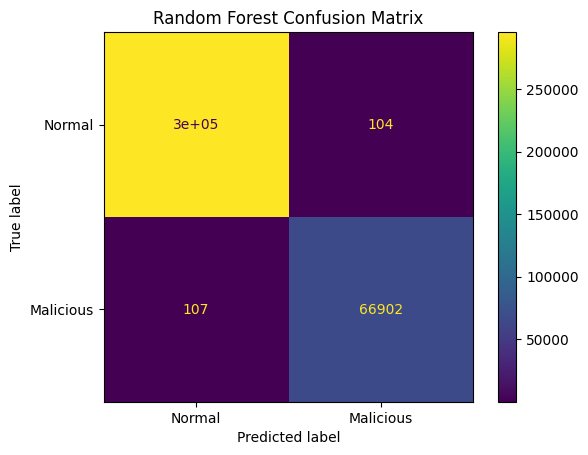

In [30]:
# Predict validation set labels
y_pred = rf_model.predict(X_val)

print("Validation Set Classification Report:")
print(classification_report(y_val, y_pred, digits=4))

f1 = f1_score(y_val, y_pred)  # Returns a decimal

f1_percent = f1 * 100  # Convert to percentage

print(f"F1 score: {f1_percent:.2f}%")
cm_rf = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Malicious"])
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

### 3.4 Baseline Evaluation - LightGBM

c:\Users\sukhp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Set Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9996    0.9998    295696
           1     0.9981    0.9998    0.9990     67009

    accuracy                         0.9996    362705
   macro avg     0.9990    0.9997    0.9994    362705
weighted avg     0.9996    0.9996    0.9996    362705

F1 score: 99.90%


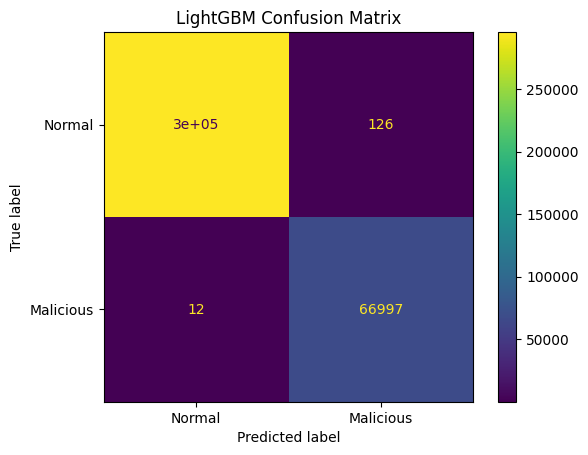

In [31]:
# Predict validation set labels
y_pred_lgbm = lgbm_model.predict(X_val)

print("Validation Set Classification Report:")
print(classification_report(y_val, y_pred_lgbm, digits=4))

f1 = f1_score(y_val, y_pred_lgbm)  # Returns a decimal
f1_percent = f1 * 100  # Convert to percentage
print(f"F1 score: {f1_percent:.2f}%")

cm_lgbm = confusion_matrix(y_val, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=["Normal", "Malicious"])
disp.plot()
plt.title("LightGBM Confusion Matrix")
plt.show()

## 4. Model Optimisation (Hyperparameter Tuning)

### 4.1 Random Forest Tuned

In [32]:
X_rf_tune, _, y_rf_tune, _ = train_test_split(X_train, y_train, train_size=120000, random_state=42, stratify=y_train)

print("RF tuning subset shape:", X_rf_tune.shape)

X_rf_tune, _, y_rf_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=120000,
    stratify=y_train,
    random_state=42
)


# RF Params to test
rf_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rf_base = RandomForestClassifier(
    class_weight="balanced", # Handle class imbalance
    n_jobs=2 , # Use all available cores for parallel processing
    random_state=42
)


# Set up RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_params,
    n_iter=4,               
    scoring="f1",
    cv=2,                     
    verbose=2,
    random_state=42,
    n_jobs=2
)

print("Starting Random Forest hyperparameter tuning")
rf_search.fit(X_rf_tune, y_rf_tune)
print("Hyperparameter tuning completed")

# Show best parameters and best F1 score
print("Best parameters found:", rf_search.best_params_)
print("Best F1 score:", rf_search.best_score_)

# Retrain the model with the best parameters on the full training set
rf_tuned = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=2,
    **rf_search.best_params_
)

rf_tuned.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred = rf_tuned.predict(X_val)


RF tuning subset shape: (120000, 45)
Starting Random Forest hyperparameter tuning
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Hyperparameter tuning completed
Best parameters found: {'n_estimators': 400, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best F1 score: 0.9954585340488957


Validation set classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997    295696
           1     0.9981    0.9991    0.9986     67009

    accuracy                         0.9995    362705
   macro avg     0.9990    0.9993    0.9991    362705
weighted avg     0.9995    0.9995    0.9995    362705

F1 score: 99.86%


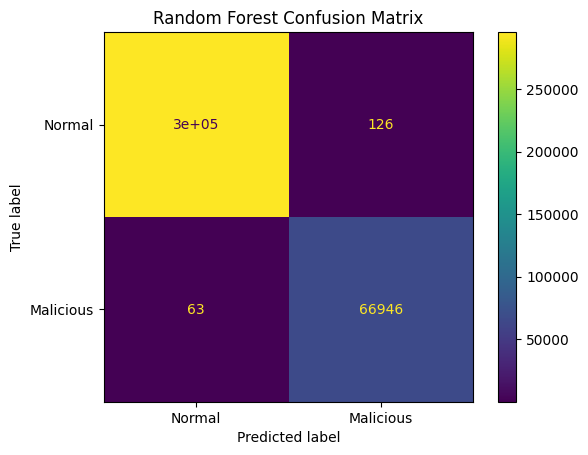

In [33]:
print("Validation set classification report:")
print(classification_report(y_val, y_val_pred, digits=4))

rf_f1 = f1_score(y_val, y_val_pred)  # Returns a decimal
rf_f1_percent = rf_f1 * 100  # Convert to percentage

print(f"F1 score: {rf_f1_percent:.2f}%")
cm_rf = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Malicious"])
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

### 4.2 LightGBM Tuned

In [34]:
# LightGBM Params to test
lgbm_params = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    "min_child_samples": [20, 50, 100],
}

lgbm_base = LGBMClassifier(
    is_unbalance=True,  # optimising for imbalance
    random_state=42,
    n_jobs=-1
)


lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_params,
    n_iter=12,           
    scoring="f1",
    cv=3,           
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting LightGBM hyperparameter tuning...")
lgbm_search.fit(X_train, y_train)
print("Hyperparameter tuning completed")

print("Best parameters found:", lgbm_search.best_params_)
print("Best F1 score (CV folds):", lgbm_search.best_score_)

y_val_pred = lgbm_search.predict(X_val)


Starting LightGBM hyperparameter tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Number of positive: 201028, number of negative: 887087
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9475
[LightGBM] [Info] Number of data points in the train set: 1088115, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.184749 -> initscore=-1.484499
[LightGBM] [Info] Start training from score -1.484499
Hyperparameter tuning completed
Best parameters found: {'num_leaves': 31, 'n_estimators': 600, 'min_child_samples': 20, 'learning_rate': 0.05}
Best F1 score (CV folds): 0.9990428786102497


c:\Users\sukhp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation set classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9996    0.9998    295696
           1     0.9982    0.9997    0.9990     67009

    accuracy                         0.9996    362705
   macro avg     0.9991    0.9997    0.9994    362705
weighted avg     0.9996    0.9996    0.9996    362705

F1 score: 99.90%


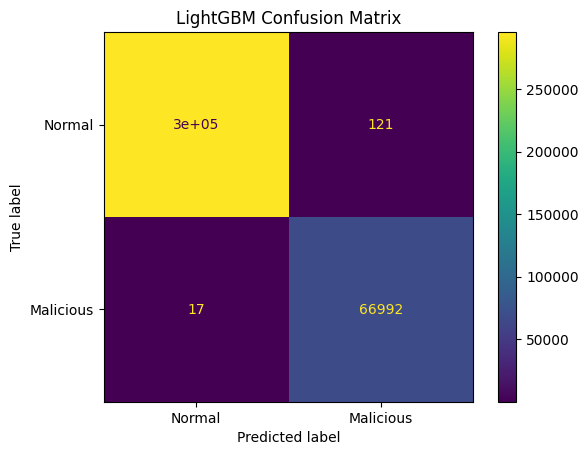

In [35]:
print("Validation set classification report:")
print(classification_report(y_val, y_val_pred, digits=4))

# F1 score as percentage
f1 = f1_score(y_val, y_val_pred)
f1_percent = f1 * 100
print(f"F1 score: {f1_percent:.2f}%")

# Confusion matrix
cm_lgbm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=["Normal", "Malicious"])
disp.plot()
plt.title('LightGBM Confusion Matrix')
plt.show()

## 5 Final Model
The LightGBM baseline model showed the best results with the highest F1-score and lowest False Negative score. Tuning it slightly improved False Positive score but equally reduced False Negative score so there wasn't much of a difference. F1-Score remained the same.

## 5.1 Final Training

Final training set shape: (1450820, 45)
Training final LightGBM model...
[LightGBM] [Info] Number of positive: 268037, number of negative: 1182783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9477
[LightGBM] [Info] Number of data points in the train set: 1450820, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.184749 -> initscore=-1.484500
[LightGBM] [Info] Start training from score -1.484500
Training complete.


c:\Users\sukhp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Final Test set classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9996    0.9998    295696
           1     0.9984    0.9998    0.9991     67010

    accuracy                         0.9997    362706
   macro avg     0.9992    0.9997    0.9994    362706
weighted avg     0.9997    0.9997    0.9997    362706

Final Test F1 score: 99.91%


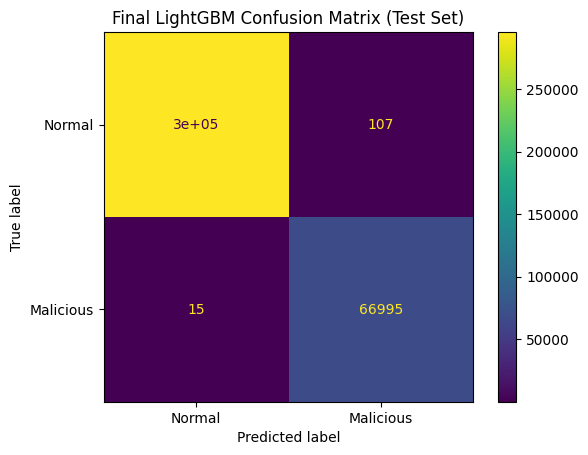

False Negatives: 15
False Positives: 107


In [36]:
# Combining training and validation sets
X_final = np.concatenate([X_train, X_val], axis=0)
y_final = np.concatenate([y_train, y_val], axis=0)

print("Final training set shape:", X_final.shape)

final_lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1
)

# Train on train + validation
print("Training final LightGBM model...")
final_lgbm.fit(X_final, y_final)
print("Training complete.")

# Evaluation on Test set
y_test_pred = final_lgbm.predict(X_test)

print("\nFinal Test set classification report:")
print(classification_report(y_test, y_test_pred, digits=4))

final_f1 = f1_score(y_test, y_test_pred)
print(f"Final Test F1 score: {final_f1 * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Malicious"]
)
disp.plot()
plt.title("Final LightGBM Confusion Matrix (Test Set)")
plt.show()

# Final analysis of false negatives and false positives
fn = cm[1, 0]
fp = cm[0, 1]
print(f"False Negatives: {fn}")
print(f"False Positives: {fp}")

## Saving Models, Code, Pre-processing Pipeline

In [ ]:
os.makedirs("models", exist_ok=True)

# Save models
joblib.dump(rf_model, "models/rf_baseline.joblib")
joblib.dump(rf_tuned, "models/rf_tuned.joblib")

joblib.dump(lgbm_model, "models/lgbm_baseline.joblib")
# Tuned LightGBM (best estimator from RandomizedSearchCV)
lgbm_tuned = lgbm_search.best_estimator_
joblib.dump(lgbm_tuned, "models/lgbm_tuned.joblib")

# Final selected model - LightGBM baseline trained on train+val
joblib.dump(final_lgbm, "models/final_model.joblib")

# save correlated features list
np.save("models/correlated_features.npy", np.array(correlated_features, dtype=object))

# save the VarianceThreshold selector object to apply the same feature selection
joblib.dump(selector, "models/variance_selector.joblib")

# Save the exact columns after correlation removal
columns_after_corr = [c for c in features.columns if c not in correlated_features]
np.save("models/columns_after_corr.npy", np.array(columns_after_corr, dtype=object))

# Final feature names after VarianceThreshold based feature removal.
final_feature_names = np.array(columns_after_corr, dtype=object)[selector.get_support()]
np.save("models/final_feature_names.npy", final_feature_names)

print("Saved models and preprocessing artefacts to ./models")
print("Final feature count after preprocessing:", len(final_feature_names))


Saved models and preprocessing artefacts to ./models
Final feature count after preprocessing: 45


## Code for Loading Final Model, Pre-processing, Testing and Re-producing Evaluation
Special imports required:

- joblib - command to install if not already installed: "pip install joblib"   (Required for opening saved models)

This code has been saved as codefortesting.py file and can be run to load the model, test it on test set and see metrics automatically.
Automatically loads the CSV files and turns into 1 df like in this notebook.

In [ ]:
import joblib
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# Get the directory this script is in
BASE_DIR = Path(__file__).resolve().parent

MODEL_DIR = BASE_DIR / "models"

# Load artefacts
print("Loading final model and preprocessing artefacts...")
final_model_loaded = joblib.load(MODEL_DIR / "final_model.joblib")
selector_loaded = joblib.load(MODEL_DIR / "variance_selector.joblib")

correlated_features_loaded = np.load(MODEL_DIR / "correlated_features.npy", allow_pickle=True).tolist()
columns_after_corr_loaded = np.load(MODEL_DIR / "columns_after_corr.npy", allow_pickle=True).tolist()
print("Loaded final model and preprocessing artefacts.")


# Help build a df from CIC-IDS2017 CSVs (using exact CSVs as in the notebook)
DATA_DIR = BASE_DIR / "CSVs"
csv_files = list(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV files found.")
df_list = []
print("\nLoading CSV files and merging into 1 singular Dataframe...")
for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)
# Merge into one DataFrame
df = pd.concat(df_list, ignore_index=True)
for d in df_list: # Free memory
    del d  
df.columns = df.columns.str.strip() # Remove leading/trailing spaces from column names which causes parsing issues
print("Created Dataframe from CSVs")

# 2) Preprocessing - Apply same steps as in notebook
print("\nPreprocessing data... (may take some time)")
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1) # Convert labels to binary (0 for Normal, 1 for Malicious)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna() # Drop rows with missing values
duplicates = df[df.duplicated()]
df = df.drop_duplicates() # Remove duplicate rows
print(f"Shape after removing duplicates: {df.shape}")


# Splitting exactly as in notebook
print("\nSplitting data into train/val/test...")
features = df.drop("Label", axis=1)
labels = df["Label"]
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.4, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

# Drop correlated features, enforce column order, apply VarianceThreshold
# Drop the same features from test split
X_test  = X_test.drop(columns=correlated_features_loaded, errors="ignore")
X_test = X_test[columns_after_corr_loaded]
X_test = selector_loaded.transform(X_test)
print ("\nDropping very highly correlated features: " + str(correlated_features_loaded))
print("Dropped low variance features using loaded VarianceThreshold selector.")

# Predict and evaluate
print("\nPredicting and evaluating on test set...")
y_test_pred_loaded = final_model_loaded.predict(X_test)
print("Predictions on test set complete.")

print("\nClassification report (loaded final model):")
print(classification_report(y_test, y_test_pred_loaded, digits=4))

final_f1 = f1_score(y_test, y_test_pred_loaded)
print(f"\nFinal Test F1 score (loaded): {final_f1 * 100:.2f}%")

cm = confusion_matrix(y_test, y_test_pred_loaded)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Malicious"])
disp.plot()
plt.title("\nFinal Model Confusion Matrix (Loaded Model, Test Set)")
plt.show()

fn = cm[1, 0]
fp = cm[0, 1]
print(f"False Negatives: {fn}")
print(f"False Positives: {fp}")
print("Finished evaluating loaded model on test set.")